# Visualizing Fire Scars Through False Color Imagery

**Author:** Ixel M.

**Link to Github Repository:** https://github.com/IIDonaji/eds220-hwk4
## About 
![palisades fire](https://upload.wikimedia.org/wikipedia/commons/1/1a/PalisadesFire_fromDowntown.png)

**Figure 1:** Palisades Fire as seen from Downtown Los Angeles (Image captured via PTZ Camera/ VMS system)

The Eaton and Palisades Fires that occurred in early January 2025 devastated thousands of homes, displaced tens of thousands of residents, and caused severe ecological and infrastructural damage. Using a combination of geospatial and tabular datasets, this notebook explores fire scars through false-color imagery derived from remote sensing data. Specifically, it uses Landsat Collection 2 Level-2 atmospherically corrected surface reflectance data collected by the Landsat 8 satellite and provided in NetCDF format, along with fire perimeter vector data in Shapefile format. Additionally, this analysis examines the social dimensions of the Eaton and Palisades Fires using the 2024 Environmental Justice Index (EJI) data for California, provided in geodatabase format.

The analysis centers on four critical technical aspect required for data integration:

1.  Data harmonization through coordinate reference systsem (CRS), which requires reprojecting spatial objects to align all geospatial layers.

2.  Vector-to-raster integration using the fire perimeter shapefile to spatially clip the mutidimensional Landsat NetCDF data.

3.  Mutli-band visulaization, focusing on generating a true-color image (RGB) by selecting and robustly scaling the correct spectral bands from the NetCDF structure.

4.  Geospatial data cleaning, which involves identifying `NaN` values to ensure data integrity and resolve plotting errors.

### About the Data:

**Landsat Collection 2 Level-2** 

Atmospherically corrected surface reflectance data, collected by Landsat 8 satellite. 
Data retrieved from [Microsof Planetary Computer data catalogue](https://planetarycomputer.microsoft.com/dataset/landsat-c2-l2) and clipped to an area surroundeding the fire perimeters.For visualization and educational purposes.  

**Dissolved Eaton and Palisades Fire Perimeters**

Features layers are publically avilable from [LA County REST web](https://egis-lacounty.hub.arcgis.com/maps/ad51845ea5fb4eb483bc2a7c38b2370c/about) ArcGIS Hub. Containing heat perimeters for the Palisades and Eaton Fires. 

**EJI Data** 

The 2024 EJI geodatabase data for California is publicaly avialble in [Agency for Toxic Substance Disease Registery (ATSDR)](https://www.atsdr.cdc.gov/place-health/php/eji/eji-data-download.html) and contains environmental, economic, and demographic data at the census track level. 


### The following packages were used in this analysis:


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import xarray as xr 
import rioxarray
import contextily as ctx

# Data Loading and Intergration for Wildfire Impact Analysis
The following code loads three key geospatial datasets for analyzing the January 2025 Southern California wildfires:
1. Wildfire Perimeter Data: Imports shapefiles containing the mapped boundaries of the Eaton and Palisades fires as of January 21, 2025, using GeoPandas for vector geometry handling.
2. Satellite Imagery: Loads Landsat 8 multispectral satellite data (NetCDF format) captured on February 23, 2025, covering both fire-affected areas using `xarray` for efficient multidimensional array processing.
3. Environmental Justice Index (EJI): Imports California's 2024 Environmental Justice Index data from a geodatabase, which provides socioeconomic and environmental health vulnerability metrics at the census tract level.
Together, these datasets enable spatial analysis combining fire extent, post-fire satellite observations, and community vulnerability indicators to assess wildfire impacts on different populations.

In [6]:
# Load wildfire perimeter data for the Eaton and Palisades fires (January 21, 2025)
eaton = gpd.read_file(
  os.path.join("data","eaton_perimeter", 
  "Eaton_Perimeter_20250121.shp"))

palisades = gpd.read_file(
  os.path.join("data","palisades_perimeter", 
  "Palisades_Perimeter_20250121.shp"))

# Import the NetCDF Landsat data using xr.open_dataset()
fp= os.path.join("data","landsat8-2025-02-23-palisades-eaton.nc" )
landsat8 = xr.open_dataset(fp)

# Import the EJI geodtabase data 
cali_eji = gpd.read_file("data/cali_eji.gpkg")

# Data Exploration and Wrangling
The following code performs initial data inspection to understand the structure and contents of the loaded datasets:

1. Fire Perimeter Metadata: 

Displays the `DataFrame` structure for both Eaton and Palisades fire shapefiles, including column names, data types, non-null counts, and memory usage to verify successful data loading and understand available attributes.

2. NetCDF Dimension Analysis: 

Examines the Landsat 8 dataset's organizational structure by printing its dimensions (spatial and temporal extents), coordinate systems (x, y coordinates and potentially time), and available data variables (spectral bands and derived products).

3. Environmental Justice Index Structure: 

Reviews the California EJI `geodatabase` structure, including census tract identifiers, vulnerability indicators, and demographic attributes to understand available metrics for analyzing disproportionate wildfire impacts on vulnerable communities.

This exploratory step is essential for understanding data organization before performing spatial analysis, ensuring the datasets are properly formatted and identifying which attributes and bands are available for subsequent wildfire impact assessment.

In [7]:
#| include: false
# Display DataFrame structure and metadata for both fire perimeters
print(f"\nEaton Fire Perimeter: ")
eaton.info()
print(f"\nPalisades Fire Perimeter:")
palisades.info()

# NetCDF exploration 
print(f"\nNetCDF Dimension Analysis:\n")
print("Dimensions:", landsat8.dims)
print("Coordinates:", list(landsat8.coords))
print("Data variables:", list(landsat8.data_vars))

# Display California EJI structure
print(f"\nCalifornia Environmental Justice Index:\n")
cali_eji.info()


Eaton Fire Perimeter: 
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    20 non-null     int32   
 1   type        20 non-null     object  
 2   Shape__Are  20 non-null     float64 
 3   Shape__Len  20 non-null     float64 
 4   geometry    20 non-null     geometry
dtypes: float64(2), geometry(1), int32(1), object(1)
memory usage: 852.0+ bytes

Palisades Fire Perimeter:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    21 non-null     int32   
 1   type        21 non-null     object  
 2   Shape__Are  21 non-null     float64 
 3   Shape__Len  21 non-null     float64 
 4   geometry    21 non-null     geometry
dtypes: float64(2), geometry(1), int32(1), object(1)
memory u

The Eaton and Palisades fire perimeter datasets stored as `GeoDataFrames` containing 20 spatial features, representing mapped fire boundary components. Each dataset includes geometric information along with attributes describing feature type and measurements of area and perimeter length, confirming that both datasets are well-structured for spatial analysis of fire extent. The remote sensing data are provided in NetCDF format and consist of a two-dimensional raster grid with multiple spectral bands including visible, near-infrared, and shortwave infrared. That are commonly used to assess burn severity and vegetation change. Together, these bands enable the creation of false-color composites and other raster-based analyses of post-fire conditions.

In addition, the California Environmental Justice Index dataset contains over 9,000 geographic features and an extensive set of demographic and environmental variables, making it suitable for evaluating how wildfire impacts intersect with social vulnerability. Combined, these datasets provide complementary spatial, spectral, and socioeconomic information necessary to analyze both the physical footprint of the fires and their potential environmental justice implications.

## Coordinate Reference System (CRS) Standardization:

When combining spatial datasets from different sources, aligning coordinate reference systems is essential for accurate spatial analysis. Here, the Landsat 8 NetCDF initially lacked an assigned CRS, which was recovered from its embedded `spatial_ref.crs_wkt` attribute, revealing the dataset was in EPSG:32611 (UTM Zone 11N). All datasets were then reprojected to match the Palisades fire perimeter's CRS (EPSG:3857) as the common reference system.


In [9]:
#| include: false
# Recover and assign CRS to Landsat
landsat8 = landsat8.rio.write_crs(landsat8.spatial_ref.crs_wkt)

# Set reference CRS and reproject all datasets
crs_reference = palisades.crs
cali_eji = cali_eji.to_crs(crs_reference)
landsat8 = landsat8.rio.reproject(crs_reference)

# Creating a False Color Image to Visualize Fire Damage

To visualize fire damage, a false color composite was created using three Landsat 8 spectral bands mapped to RGB channels:

| Band  | What it reveals                         |
|-------|-----------------------------------------|
| SWIR2 | Burned areas, moisture content          |
| NIR   | Healthy vegetation (appears bright red) |
| Red   | Urban surfaces, bare soil               |

This combination makes fire damage immediately visible, burned areas appear dark brown or black, healthy vegetation appears bright red, and urban areas render as gray-green. NaN values in the satellite data were filled with zeros to prevent plotting errors.

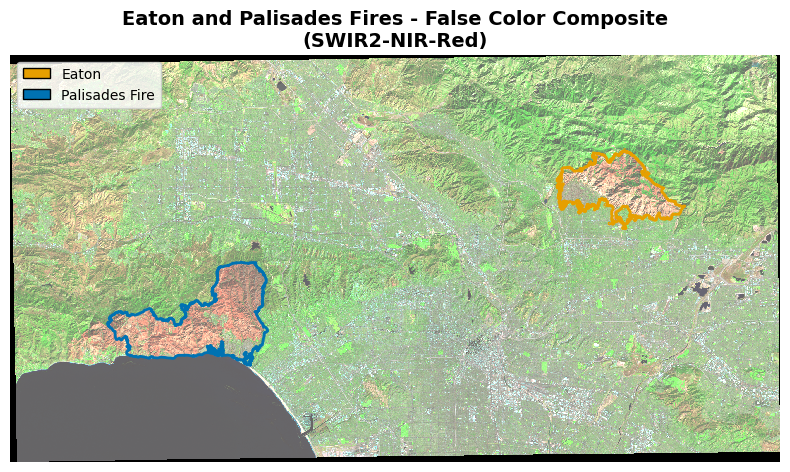

In [19]:
#| echo: false
# Plot false color image swir22/nir08/red
fig, ax = plt.subplots(figsize= (8, 10))
# Plot false color image swir22/nir08/red 
bands =  landsat8[["swir22", "nir08", "red"]].to_array().fillna(0)
bands.plot.imshow(
ax = ax, # assign axis
robust= True) # removes cloud cover
# Set Fire perimeter legend format
eaton_patch = mpatches.Patch(facecolor = "#E69F00", 
                             edgecolor = "black", label= "Eaton")
palisades_patch = mpatches.Patch(facecolor = "#0072B2", 
                                 edgecolor = "black", label= "Palisades Fire" )
                                 
#  Plot fire perimeters with edgecolor representation 
eaton.plot(ax=ax, facecolor= 'none', 
           edgecolor= '#E69F00', 
           linewidth= 2, 
           label= 'Eaton Fires')
palisades.plot(ax=ax, facecolor= 'none', 
               edgecolor= '#0072B2', 
               linewidth= 2, 
               label= 'Palisades Fires')

# add legend if not using name lables
ax.legend(handles = [eaton_patch, palisades_patch], 
          loc='upper left', fontsize= 10) 
# Set title
ax.set_title('Eaton and Palisades Fires - False Color Composite\n(SWIR2-NIR-Red)', 
             fontsize= 14, fontweight='bold')
# Turn axis off for readability
ax.set_axis_off()
plt.tight_layout()
# Print map
plt.show()

### False Color Composition Map Description

The map features a false-color composite created from Landsat 8 data, depicting the regions affected by the Eaton and Palisades Fires. By combining SWIR, NIR, and red spectral bands, the image accentuates differences between healthy vegetation and burned terrain. Areas with intact vegetation appear bright green due to strong NIR reflectance, while fire-damaged zones appear in shades of reddish brown. Yellow and red outlines mark the Eaton and Palisades fire perimeters, clearly showing the extent of each fire. This type of false-color imagery is widely used to assess burn severity and understand how landscapes recover over time.

# Identifying Affected Communities

To assess which communities were impacted, census tracts from the 2024 EJI dataset were matched to each fire using two approaches. First, a spatial join (`gpd.sjoin`) identified all census tracts that intersected the fire boundaries, however this includes entire tract boundaries even if only a small portion overlaps, overestimating the affected area. Clipping (`gpd.clip`) was then used to cut the census tracts precisely to the fire boundary, providing a more accurate representation of the affected area. The EJI variable EPL_POV200, the poverty percentile for households below 200% of the federal poverty line, was used to compare socioeconomic vulnerability across both fire footprints.

In [12]:
#| include: false
# Find census tracts that intersect with Palisades fire
eji_palisades = gpd.sjoin(cali_eji, palisades, predicate="intersects")

# Find census tracts that intersect with Eaton fire
eji_eaton = gpd.sjoin(cali_eji, eaton, predicate="intersects")

# Clip census tracts to Palisades fire boundary
eji_palisades_clip = gpd.clip(cali_eji, palisades)

# Clip census tracts to Eaton fire boundary
eji_eaton_clip = gpd.clip(cali_eji, eaton)

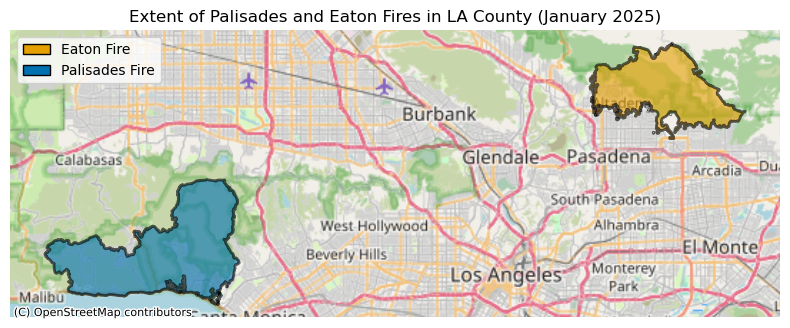

In [20]:
#| echo: false
# Create figure
fig, ax = plt.subplots(figsize=(8, 10))

# Create legend patches
palisades_patch = mpatches.Patch(facecolor="#0072B2", edgecolor="black", label="Palisades Fire")
eaton_patch = mpatches.Patch(facecolor="#E69F00", edgecolor="black", label="Eaton Fire")

# Plot fire perimeters
palisades.plot(ax=ax, facecolor="#0072B2", edgecolor="black", alpha=0.6, linewidth=2)
eaton.plot(ax=ax, facecolor="#E69F00", edgecolor="black", alpha=0.6, linewidth=2)

# Add OpenStreetMap basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# Add legend and title
ax.legend(handles=[eaton_patch, palisades_patch], loc="upper left")
ax.set_title("Extent of Palisades and Eaton Fires in LA County (January 2025)")
ax.axis('off')

plt.tight_layout()
plt.show()

This maps the Eaton and Palisades fire perimeters overlaid on an OpenStreetMap basemap, situating both fires within the broader LA County geography.

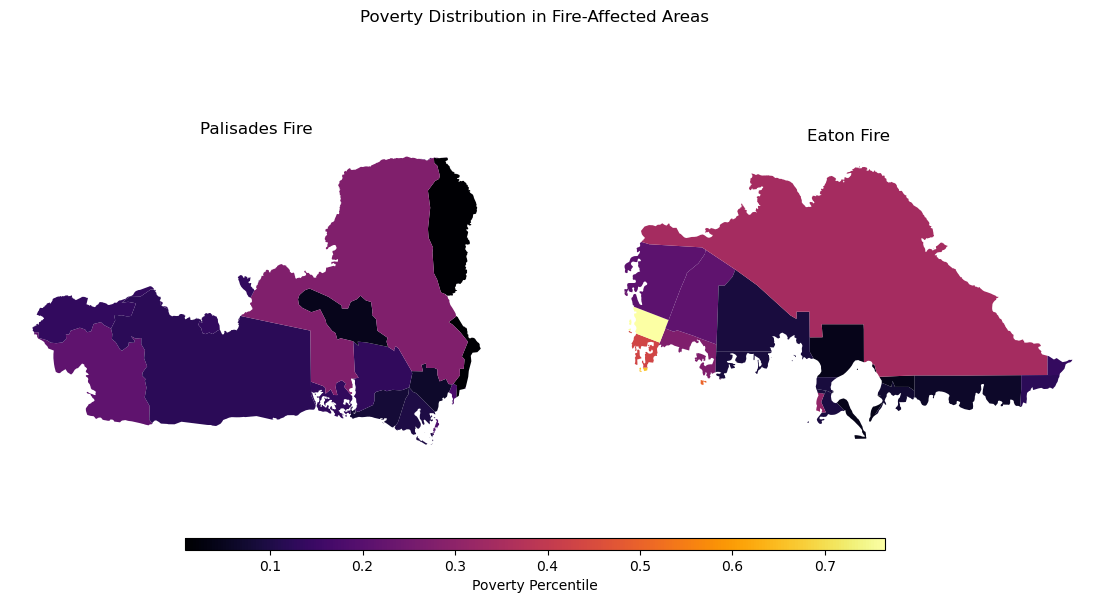

In [22]:
#| echo: false
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Select an EJI variable (e.g., poverty percentile)
eji_variable = 'EPL_POV200'

# Find common color scale range for both maps
vmin = min(eji_palisades_clip[eji_variable].min(), eji_eaton_clip[eji_variable].min())
vmax = max(eji_palisades_clip[eji_variable].max(), eji_eaton_clip[eji_variable].max())

# Plot Palisades census tracts colored by poverty level
eji_palisades_clip.plot(
    column=eji_variable,
    vmin=vmin, vmax=vmax,
    legend=False,
    ax=ax1,
    cmap="inferno"
)
ax1.set_title('Palisades Fire')
ax1.axis('off')

# Plot Eaton census tracts colored by poverty level
eji_eaton_clip.plot(
    column=eji_variable,
    vmin=vmin, vmax=vmax,
    legend=False,
    ax=ax2,
    cmap="inferno"
)
ax2.set_title('Eaton Fire')
ax2.axis('off')

# Add overall title
fig.suptitle('Poverty Distribution in Fire-Affected Areas')

# Add shared colorbar
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap="inferno")
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Poverty Percentile')

plt.show()

## Description of Poverty Distribution Map

The analysis of fire impact across socioeconomic groups showed significant variation between the two events. The Palisades Fire disproportionately affected lower-poverty communities, particularly those closer to the coastline. Conversely, the Eaton Fire impacted a higher overall percentage of low income communities, with the highest-poverty tracts generally located in the mountainous areas. This disparity highlights how wildfire consequences are strongly influenced by the socioeconomic status and geographic location of the affected neighborhoods.

### Data References

Bren School of Environmental Science and Management. (2025). landsat8-2025-02-23-palisades-eaton.nc \[Dataset\]. Accessed November 20, 2025, from https://drive.google.com/drive/u/1/folders/1USqhiMLyN8GE05B8WJmHabviJGnmAsLP

Centers for Disease Control and Prevention and Agency for Toxic Substances Disease Registry. (2024). 2024 Environmental Justice Index. \[Dataset\]. Accessed December 2, 2025, from https://atsdr.cdc.gov/place-health/php/eji/eji-data-download.html

County of Los Angeles Enterprise GIS. (2025). Palisades and Eaton Dissolved Fire Perimeters (2025) \[Dataset\]. County of Los Angeles. Accessed November 20, 2025, from https://egis-lacounty.hub.arcgis.com/maps/ad51845ea5fb4eb483bc2a7c38b2370c/about

Microsoft Planetary Computer. (n.d.). Landsat Collection 2 Level-2. Accessed November 20, 2025, from https://planetarycomputer.microsoft.com/dataset/landsat-c2-l2
